## Code 목차 


- [1. 분석환경 구축]
   - [1.1라이브러리 임포트]  
         


- [2. 데이터 읽기]
    - [2.1 데이터 조정]
    - [2.2 데이터 통합]


- [3. 데이터 전처리]
    - [3.1 결측치 확인 및 열 제거]
    - [3.2 데이터 탐색 및 열 조정]
    - [3.3 원-핫 인코딩]
    - [3.4 클러스터링 열 생성]
    - [3.5 수치형열 평균/표준편차 열 생성]
    - [3.6 다중공선성 확인 및 PCA 열 생성]
    

- [4. 모델링]
    - [4.1 AutoML pycaret]
    - [4.2 릿지 회귀 모델]
    - [4.3 랜덤 포레스트 모델]
    - [4.4 최종 모델 구축]
    - [4.5 결과 해석]
    - [4.6 예측 결과 파일 제출]

<a name='01'></a>
## 1. 분석환경 구축 

<a name='01-01'></a>
### 1.1 라이브러리 임포트

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import requests
from bs4 import BeautifulSoup
import warnings
import time
warnings.filterwarnings('ignore')


import numpy as np
import pandas as pd
import scipy as sp
import statsmodels.api as sm
from datetime import datetime, date, timedelta
from sklearn.preprocessing import StandardScaler, LabelEncoder


import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew, norm, probplot, boxcox
from itertools import product

# 모델링을 위한 라이브러리
from sklearn.decomposition import PCA
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_squared_log_error
from math import sqrt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_selection import SelectKBest, mutual_info_regression, VarianceThreshold, RFECV
from catboost import CatBoostRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

import lightgbm as lgb
import xgboost
import xgboost as xgb
from sklearn.ensemble import ExtraTreesRegressor
from xgboost import XGBRegressor
from pycaret.datasets import get_data
from pycaret.classification import *
import optuna
from pycaret.regression import *
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 폰트 경로를 설정
path = '/System/Library/Fonts/Supplemental/AppleGothic.ttf'
font_name = fm.FontProperties(fname=path, size=50).get_name()

# 폰트 설정
plt.rc('font', family=font_name)

# 마이너스 기호 깨짐 방지
plt.rc('axes', unicode_minus=False)

<a name='02'></a>
## 2. 데이터 읽기

데이터 파일을 불러옵니다.

In [ ]:
files = [
    "2023_strong_sme_government.xlsx",
    "youth_worknet_crawling.csv"
]

In [ ]:
files = [
    "2023_strong_sme_government.xlsx",
    "youth_worknet_crawling.csv"
]
dataframes = {}

for file in files:
    file_name, file_ext = os.path.splitext(file)
    if file_ext == '.csv':
        try:
            dataframes[file_name] = pd.read_csv(file, encoding='utf-8-sig')
        except UnicodeDecodeError:
            dataframes[file_name] = pd.read_csv(file, encoding='CP949')
    elif file_ext == '.xlsx':
        dataframes[file_name] = pd.read_excel(file, engine='openpyxl')

In [ ]:
# 고용노동부 강소기업 게시용 데이터 import
g23 = dataframes['2023_strong_sme_government']

In [ ]:
# 청년 워크넷 강소기업선정 크롤링 데이터 import
g23c = dataframes['youth_worknet_crawling']

<a name='02-01'></a>
### 2.1 데이터 조정

데이터 병합을 위한 조정작업을 진행합니다. 


In [6]:
#연번 4글자화 
g23['연번'] = g23['연번'].str.slice(0, 4)
#업종명 조정 
g23 = g23.rename(columns={'업종명\n(대분류)': '업종(대분류)', '업종명\n(중분류)': '업종(중분류)'})
g23= g23.drop(columns=['업종(대분류)'])
g23
# print(g23.head())
# print(len(g23))

,연번,브랜드명,사업장명,대표자명,업종(중분류),주소
0,2023,신청기업,동진산업,조만석 외 1명,"펄프, 종이 및 종이제품 제조업",대구 달성군 옥포읍 시저로 92-7
1,2023,신청기업,주식회사 필텍,이종필,"전자부품, 컴퓨터, 영상, 음향 및 통신장비 제조업","경기도 용인시 기흥구 구성로 357 (청덕동, 용인테크노밸리) D동 207호"
2,2023,신청기업,㈜지에스씨넷,박용수,전문 서비스업,"세종 한누리대로 219 4층 401, 402호 (나성동, 한림프라자)"
3,2023,신청기업,㈜에이팀벤처스,고산,출판업,"서울 서초구 나루터로 60 3층 (잠원동, 정원빌딩)"
4,2023,신청기업,웅진식품㈜,이지호,음료 제조업,충남 공주시 유구읍 유구마곡사로 136-24
...,...,...,...,...,...,...
27785,2023,병역지정업체,(주)워솔케이제이티,곽필규,화학물질 및 화학제품 제조업; 의약품 제외,충북 음성군 음성읍 음성로 449
27786,2023,병역지정업체,(주)위드펜스터여주공장,김재성,금속가공제품 제조업; 기계 및 가구 제외,경기 여주시 산북면 광여로 1225-10 (상품리 48-5 외 2필지)
27787,2023,병역지정업체,(주)유니온,강대창,"전자부품, 컴퓨터, 영상, 음향 및 통신장비 제조업",경남 창원시 의창구 차룡로14번길 17 (팔용동)
27788,2023,병역지정업체,재욱강업(주),조여근,1차 금속 제조업,경북 성주군 선남면 문방공단길 129-50


In [7]:
g23c
# print(g23c.head())
# print(len(g23c))

,기업명,선정분야,업종/규모,근로자수,소재지,관심기업,직원수,기업규모,소재지(대),소재지(중),관심기업건수
0,( 주)식스티세컨즈,경영혁신형 중소기업(메인비즈),제조업,중소기업 0명,서울 강남구,1건,0,중소기업,서울,강남구,1
1,(명)스카이여행사,경영혁신형 중소기업(메인비즈),"사업시설 관리, 사업 지원 및 임대 서비스업",중소기업 22명,강원 태백시,0건,22,중소기업,강원,태백시,0
2,(유한)대길시피,안전보건경영시스템 인증기업,제조업,중소기업 0명,전남 여수시,5건,0,중소기업,전남,여수시,5
3,(유한)대원,안전보건경영시스템 인증기업,제조업,중소기업 0명,충남 서천군,36건,0,중소기업,충남,서천군,36
4,(유한)신성종합개발,안전보건경영시스템 인증기업,"사업시설 관리, 사업 지원 및 임대 서비스업",중소기업 60명,전북 군산시,5건,60,중소기업,전북,군산시,5
...,...,...,...,...,...,...,...,...,...,...,...
27775,(주)힐엔지니어링,기술혁신형 중소기업(이노비즈),"전문, 과학 및 기술 서비스업",중소기업 26명,부산 사상구,2건,26,중소기업,부산,사상구,2
27776,주식회사힐코,경영혁신형 중소기업(메인비즈),도매 및 소매업,중소기업 4명,경기 파주시,2건,4,중소기업,경기,파주시,2
27777,힘내라병원,대한민국일자리으뜸기업,NaN,0명,부산 동구,0건,0,알수없음,부산,동구,0
27778,(주)힘멘테크,경영혁신형 중소기업(메인비즈),제조업,중소기업 49명,경기 안양시 동안구,3건,49,중소기업,경기,안양시,3


<a name='02-02'></a>
### 2.2 데이터 통합 

고용노동부 강소기업 데이터 (g23)과   

청년워크넷 크롤링데이터  (g23c)를   


기업명, 사업장명 을 기준으로 left merge 진행합니다.


In [8]:
overlap = g23['사업장명'].isin(g23c['기업명'])
len(overlap)

27790

In [9]:
merged_df = g23c.merge(g23, left_on='기업명', right_on='사업장명', how='left')
print(merged_df.head())

          기업명              선정분야                     업종/규모      근로자수     소재지  \
0  ( 주)식스티세컨즈  경영혁신형 중소기업(메인비즈)                       제조업   중소기업 0명  서울 강남구   
1   (명)스카이여행사  경영혁신형 중소기업(메인비즈)  사업시설 관리, 사업 지원 및 임대 서비스업  중소기업 22명  강원 태백시   
2    (유한)대길시피    안전보건경영시스템 인증기업                       제조업   중소기업 0명  전남 여수시   
3      (유한)대원    안전보건경영시스템 인증기업                       제조업   중소기업 0명  충남 서천군   
4  (유한)신성종합개발    안전보건경영시스템 인증기업  사업시설 관리, 사업 지원 및 임대 서비스업  중소기업 60명  전북 군산시   

  관심기업  직원수  기업규모 소재지(대) 소재지(중)  관심기업건수    연번            브랜드명        사업장명  \
0   1건    0  중소기업     서울    강남구       1  2023            메인비즈  ( 주)식스티세컨즈   
1   0건   22  중소기업     강원    태백시       0  2023            메인비즈   (명)스카이여행사   
2   5건    0  중소기업     전남    여수시       5  2023  안전보건경영시스템 인증기업    (유한)대길시피   
3  36건    0  중소기업     충남    서천군      36  2023  안전보건경영시스템 인증기업      (유한)대원   
4   5건   60  중소기업     전북    군산시       5  2023  안전보건경영시스템 인증기업  (유한)신성종합개발   

  대표자명                  업종(중분류)                               

<a name='03'></a>
## 3. 데이터 전처리   



<a name='03-01'></a>
### 3.1 결측치 확인 및 열 조정

In [10]:
#결측치 확인
missing_rows = merged_df[merged_df.isnull().any(axis=1)]
len(missing_rows)

2656

In [11]:
missing_cols = merged_df.columns[merged_df.isnull().any()].tolist()
print(missing_cols)

['업종/규모', '소재지(중)', '연번', '브랜드명', '사업장명', '대표자명', '업종(중분류)', '주소']


In [12]:
# 기존에 있던 '연번' 컬럼을 제거합니다.
if '연번' in merged_df.columns:
    merged_df = merged_df.drop(columns=['연번'])


In [13]:
# '소재지', '근로자수', '업종/규모', '주소' 열을 제거합니다.
merged_df = merged_df.drop(columns=['소재지', '근로자수', '업종/규모', '주소'])


In [14]:
missing_cols = merged_df.columns[merged_df.isnull().any()].tolist()
print(missing_cols)

['소재지(중)', '브랜드명', '사업장명', '대표자명', '업종(중분류)']


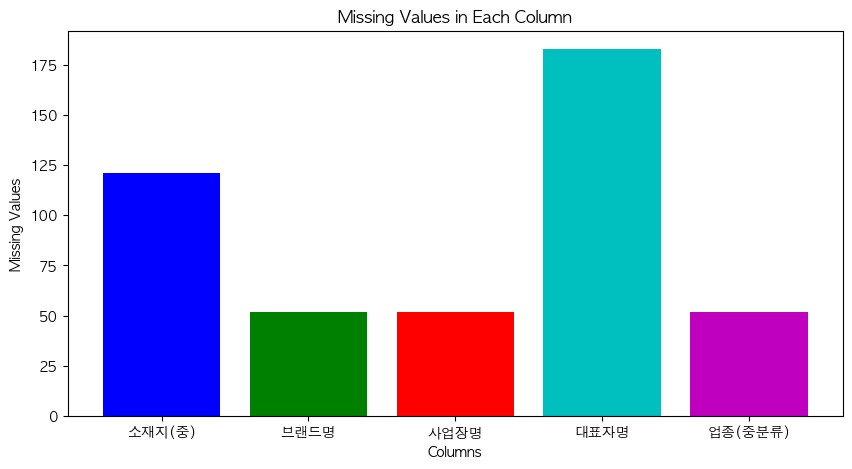

In [15]:
import matplotlib.pyplot as plt
import numpy as np

cols = ['소재지(중)', '브랜드명', '사업장명', '대표자명', '업종(중분류)']
missing_values = []

for col in cols:
    missing_count = merged_df[col].isnull().sum()
    missing_values.append(missing_count)

colors = ['b', 'g', 'r', 'c', 'm']  # blue, green, red, cyan, magenta

plt.figure(figsize=(10, 5))
plt.bar(cols, missing_values, color=colors)
plt.xlabel('Columns')
plt.ylabel('Missing Values')
plt.title('Missing Values in Each Column')
plt.show()


In [16]:
cols = ['소재지(중)', '브랜드명', '사업장명', '대표자명', '업종(중분류)']

for col in cols:
    missing_count = merged_df[col].isnull().sum()
    print(f"Missing values in {col}: {missing_count}")

Missing values in 소재지(중): 121
Missing values in 브랜드명: 52
Missing values in 사업장명: 52
Missing values in 대표자명: 183
Missing values in 업종(중분류): 52


In [17]:
# 결측치가 있는 행 확인
missing_rows = merged_df[merged_df.isnull().any(axis=1)]
print(len(missing_rows))

304


In [18]:
# 결측치 행 삭제 
merged_df = merged_df.dropna()
len(merged_df)

28798

In [19]:
# '선정분야' 열 삭제
merged_df = merged_df.drop('선정분야', axis=1)

# '관심기업' 열에서 '건' 문자를 제거하고 정수로 변환
merged_df['관심기업'] = merged_df['관심기업'].str.replace('건', '').astype(int)

# '사업장명' 열 삭제
merged_df = merged_df.drop('사업장명', axis=1)

In [20]:
#관심기업건수 열 삭제 , 관심기업과 중복 
merged_df = merged_df.drop('관심기업건수', axis=1)

In [21]:
# '직원수'가 0인 기업명 찾기
zero_employee_companies = merged_df[merged_df['직원수'] == 0]['기업명']
print(zero_employee_companies)

0        ( 주)식스티세컨즈
2          (유한)대길시피
3            (유한)대원
7         (유한)한독이앤티
13        (자)어반스케이프
            ...    
29081        희망테크프론
29082     주식회사희성다이텍
29086       주식회사 희창
29090      주식회사 히키스
29095        (주)힐링팜
Name: 기업명, Length: 3994, dtype: object


In [22]:
# 인덱스 재설정
merged_df = merged_df.reset_index(drop=True)
merged_df

,기업명,관심기업,직원수,기업규모,소재지(대),소재지(중),브랜드명,대표자명,업종(중분류)
0,( 주)식스티세컨즈,1,0,중소기업,서울,강남구,메인비즈,조재만,섬유제품 제조업; 의복제외
1,(명)스카이여행사,0,22,중소기업,강원,태백시,메인비즈,신재희,육상운송 및 파이프라인 운송업
2,(유한)대길시피,5,0,중소기업,전남,여수시,안전보건경영시스템 인증기업,김범수,화학물질 및 화학제품 제조업; 의약품 제외
3,(유한)대원,36,0,중소기업,충남,서천군,안전보건경영시스템 인증기업,양준호,"펄프, 종이 및 종이제품 제조업"
4,(유한)신성종합개발,5,60,중소기업,전북,군산시,안전보건경영시스템 인증기업,박정열,1차 금속 제조업
...,...,...,...,...,...,...,...,...,...
28793,주식회사힐링페이퍼,0,123,중소기업,서울,강남구,병역지정업체,홍승일,출판업
28794,(주)힐엔지니어링,2,26,중소기업,부산,사상구,이노비즈,우종열,"건축기술, 엔지니어링 및 기타 과학기술 서비스업"
28795,주식회사힐코,2,4,중소기업,경기,파주시,메인비즈,오성철,소매업; 자동차 제외
28796,(주)힘멘테크,3,49,중소기업,경기,안양시,메인비즈,김상해,"전자부품, 컴퓨터, 영상, 음향 및 통신장비 제조업"


<a name='03-02'></a>
### 3.2 데이터 탐색 및 열 조정

이노비즈                14926
메인비즈                 7107
병역지정업체               1863
신청기업                 1359
가족친화인증기업              703
사회적기업                 636
인재육성형 중소기업            520
안전보건경영시스템 인증기업        488
세계일류상품                447
근무혁신우수기업              150
유망중소기업                103
서울형 강소기업               71
월드클래스300               70
한국형 히든챔피언 육성프로그램       64
유망중소기업                 44
노사문화우수기업               34
향토기업                   24
여가친화기업                 16
전략산업 선도기업              13
최고일자리기업                13
명품강소기업                 12
이달의 기능한국인              12
백년기업                   12
고용우수기업                 10
청년일자리창출우수기업            10
남녀고용평등우수기업              9
월드클래스플러스                9
고용친화기업                  9
일자리우수기업                 6
울산 지역스타기업               6
PRE-명품강소기업              5
일자리창출 우수기업              5
경남형 청년친화기업              5
고용우수기업                  5
코스닥 라이징스타               4
글로벌강소기업                 4
2021년 좋은일터 인증기업         3
우리지역 청년 희망이음 기업         3
신보스타기업      

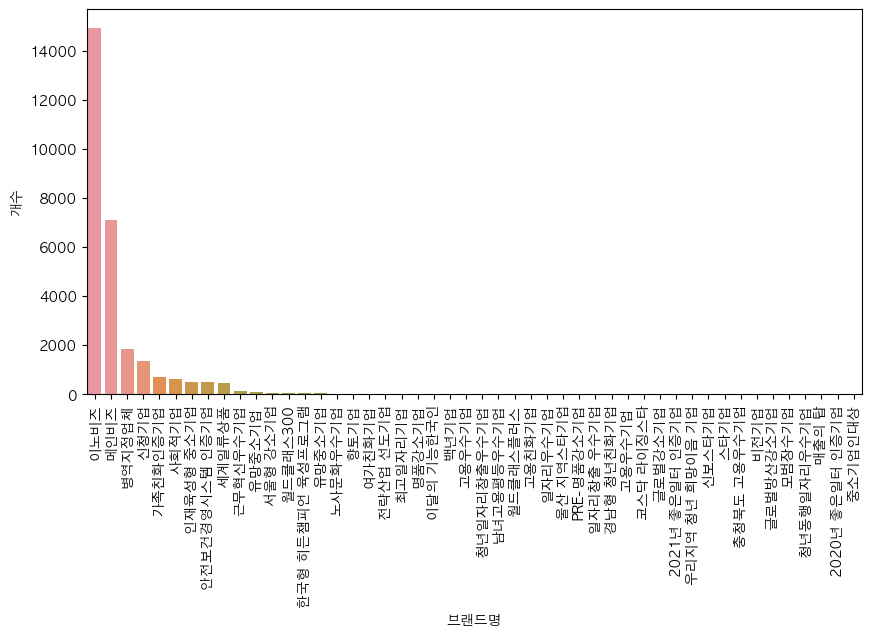

In [23]:
# 브랜드명 별 데이터 개수 세기
brand_counts = merged_df['브랜드명'].value_counts()

# 수치적 결과 출력
print(brand_counts)

# 시각적 결과 출력
plt.figure(figsize=(10,5))
sns.barplot(x=brand_counts.index, y=brand_counts.values)
plt.xlabel('브랜드명')
plt.ylabel('개수')
plt.xticks(rotation=90)  # X축 레이블 회전 (필요하면 사용)
plt.show()

제조업 데이터 개수: 18026
비제조업 데이터 개수: 10772


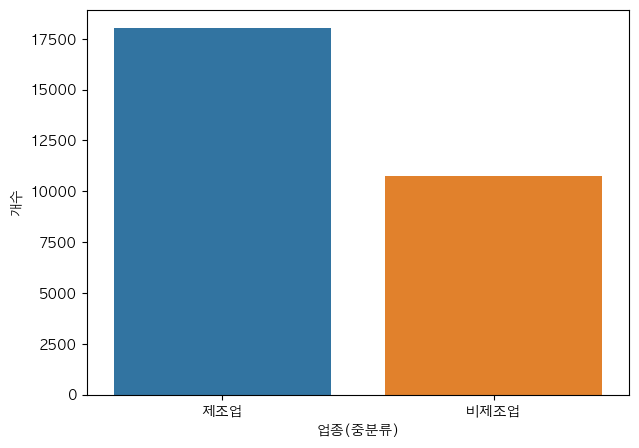

In [24]:
# '제조업'이라는 단어가 들어간 데이터와 그렇지 않은 데이터 분리
manufacturing = merged_df[merged_df['업종(중분류)'].str.contains('제조업')]
non_manufacturing = merged_df[~merged_df['업종(중분류)'].str.contains('제조업')]

# 수치적 결과 출력
print("제조업 데이터 개수:", len(manufacturing))
print("비제조업 데이터 개수:", len(non_manufacturing))

# 시각적 결과 출력
plt.figure(figsize=(7,5))
sns.barplot(x=['제조업', '비제조업'], y=[len(manufacturing), len(non_manufacturing)])
plt.xlabel('업종(중분류)')
plt.ylabel('개수')
plt.show()

경기    9275
서울    5324
경남    1856
인천    1639
경북    1552
부산    1497
충남    1406
대구    1207
충북    1092
전남     814
대전     756
전북     616
광주     571
강원     520
울산     499
제주     174
Name: 소재지(대), dtype: int64


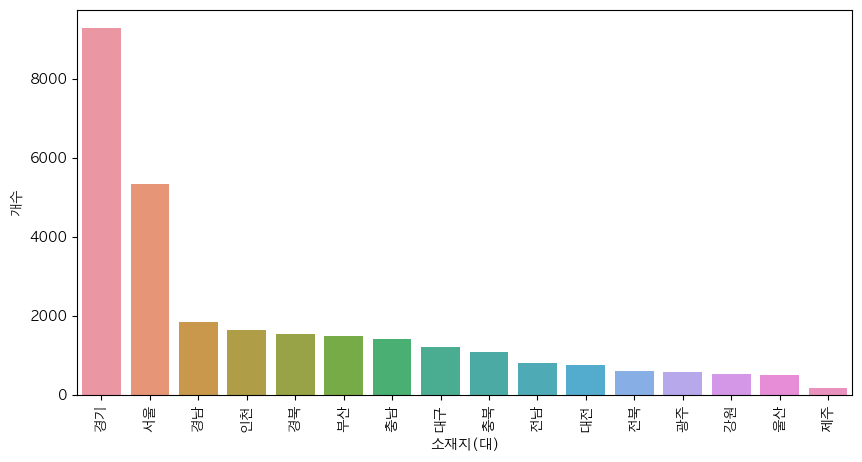

In [25]:
# '소재지(대)' 별 데이터 개수 세기
location_counts = merged_df['소재지(대)'].value_counts()

# 수치적 결과 출력
print(location_counts)

# 시각적 결과 출력
plt.figure(figsize=(10,5))
sns.barplot(x=location_counts.index, y=location_counts.values)
plt.xlabel('소재지(대)')
plt.ylabel('개수')
plt.xticks(rotation=90)  # X축 레이블 회전 (필요하면 사용)
plt.show()

In [26]:
final_df = merged_df.copy()

In [27]:
 #'업종(중분류)' 열에서 '제조업'이 들어가면 '제조업'으로 바꾸기
final_df['업종(중분류)'] = final_df['업종(중분류)'].apply(lambda x: '제조업' if '제조업' in x else x)
final_df.head()

,기업명,관심기업,직원수,기업규모,소재지(대),소재지(중),브랜드명,대표자명,업종(중분류)
0,( 주)식스티세컨즈,1,0,중소기업,서울,강남구,메인비즈,조재만,제조업
1,(명)스카이여행사,0,22,중소기업,강원,태백시,메인비즈,신재희,육상운송 및 파이프라인 운송업
2,(유한)대길시피,5,0,중소기업,전남,여수시,안전보건경영시스템 인증기업,김범수,제조업
3,(유한)대원,36,0,중소기업,충남,서천군,안전보건경영시스템 인증기업,양준호,제조업
4,(유한)신성종합개발,5,60,중소기업,전북,군산시,안전보건경영시스템 인증기업,박정열,제조업


In [28]:
final_df.nunique()

기업명        26930
관심기업         207
직원수          584
기업규모           5
소재지(대)        16
소재지(중)       205
브랜드명          48
대표자명       20790
업종(중분류)       46
dtype: int64

In [29]:
duplicated_df = final_df[final_df.duplicated(subset=['기업명'], keep=False)]

# 중복된 기업명을 확인
print(len(duplicated_df['기업명'].unique()))

483


In [30]:
# 아래의 코드는 '기업명' 열에서 각 기업이 얼마나 자주 나타나는지 계산하고, 이 정보를 '기업개수'라는 새로운 열로 추가합니다:
final_df['기업개수'] = final_df.groupby('기업명')['기업명'].transform('count')


In [31]:
# '기업명'과 '대표자명'으로 그룹화 후, 그룹별 데이터 수 (행의 수)를 셈
grouped = final_df.groupby(['기업명', '대표자명']).size().reset_index(name='counts')

# '기업명'으로 다시 그룹화하고, 각 그룹별 '대표자명' 수를 세어 '대표자수' 열을 생성
final_df_with_rep_count = grouped.groupby('기업명')['대표자명'].count().reset_index(name='대표자수')

# 원래의 final_df와 결합
final_df = pd.merge(final_df, final_df_with_rep_count, on='기업명')

In [32]:
# 기업명에 따라 고유한 브랜드명의 수를 계산합니다.
brand_counts = final_df.groupby('기업명')['브랜드명'].nunique()

# '브랜드신청수'라는 새 열을 생성하고 계산한 값을 할당합니다.
final_df = final_df.assign(브랜드신청수=final_df['기업명'].map(brand_counts))


In [33]:
final_df['브랜드신청수'].max()

3

In [34]:
final_df = final_df.drop_duplicates(subset=['기업명', '소재지(대)', '소재지(중)'])
# 기업명인데 소재지가 같은기업들 하나로 만들기

In [35]:
# final_df.to_csv("for_again2.csv",index = False)

In [36]:
df_again2 = pd.read_csv("for_again2.csv")

# Displaying basic information of the dataset
df_again2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27477 entries, 0 to 27476
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   기업명      27477 non-null  object
 1   관심기업     27477 non-null  int64 
 2   직원수      27477 non-null  int64 
 3   기업규모     27477 non-null  object
 4   소재지(대)   27477 non-null  object
 5   소재지(중)   27477 non-null  object
 6   브랜드명     27477 non-null  object
 7   대표자명     27477 non-null  object
 8   업종(중분류)  27477 non-null  object
 9   기업개수     27477 non-null  int64 
 10  대표자수     27477 non-null  int64 
 11  브랜드신청수   27477 non-null  int64 
dtypes: int64(5), object(7)
memory usage: 2.5+ MB


In [37]:
np.mean(df_again2['관심기업'])

11.103359173126615

In [38]:
df_again2['직원수'].describe() 
#평균 49.3
# 5007
# 

count    27477.000000
mean        49.303709
std         99.542721
min          0.000000
25%         13.000000
50%         25.000000
75%         51.000000
max       5007.000000
Name: 직원수, dtype: float64

In [42]:
a = df_again2.describe() 
# a.to_csv('디스크라이브.csv',index =False)

In [39]:
# '기업규모' 컬럼에서 '알수없음'을 '중소기업'으로 변경
df_again2['기업규모'] = df_again2['기업규모'].replace('알수없음', '중소기업')



In [40]:
(df_again2['기업규모'].value_counts(normalize=True) * 100)


중소기업    97.619827
중견기업     2.278269
기타       0.083706
대기업      0.018197
Name: 기업규모, dtype: float64

In [41]:
def remove_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # 이상치 행 제거
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    
    return df
columns_to_check = ['직원수', '기업개수', '브랜드신청수', '대표자수']
df_again2 = remove_outliers(df_again2, columns_to_check)
remaining_rows_after_removal = df_again2.shape[0]
remaining_rows_after_removal

23778

In [42]:
df_again2['제조업_if'] = df_again2['업종(중분류)'].apply(lambda x: 1 if '제조업' in x else 0)
df_again2['서비스업_if'] = df_again2['업종(중분류)'].apply(lambda x: 1 if '서비스업' in x else 0)

In [43]:
(df_again2['제조업_if'].value_counts(normalize=True) * 100)

1    61.115317
0    38.884683
Name: 제조업_if, dtype: float64

In [44]:
df_again2

,기업명,관심기업,직원수,기업규모,소재지(대),소재지(중),브랜드명,대표자명,업종(중분류),기업개수,대표자수,브랜드신청수,제조업_if,서비스업_if
0,( 주)식스티세컨즈,1,0,중소기업,서울,강남구,메인비즈,조재만,제조업,1,1,1,1,0
1,(명)스카이여행사,0,22,중소기업,강원,태백시,메인비즈,신재희,육상운송 및 파이프라인 운송업,1,1,1,0,0
2,(유한)대길시피,5,0,중소기업,전남,여수시,안전보건경영시스템 인증기업,김범수,제조업,1,1,1,1,0
3,(유한)대원,36,0,중소기업,충남,서천군,안전보건경영시스템 인증기업,양준호,제조업,1,1,1,1,0
4,(유한)신성종합개발,5,60,중소기업,전북,군산시,안전보건경영시스템 인증기업,박정열,제조업,1,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27471,(주)힐링팜,19,0,중소기업,경기,수원시,메인비즈,권기영,도매 및 상품 중개업,1,1,1,0,0
27473,(주)힐엔지니어링,2,26,중소기업,부산,사상구,이노비즈,우종열,"건축기술, 엔지니어링 및 기타 과학기술 서비스업",1,1,1,0,1
27474,주식회사힐코,2,4,중소기업,경기,파주시,메인비즈,오성철,소매업; 자동차 제외,1,1,1,0,0
27475,(주)힘멘테크,3,49,중소기업,경기,안양시,메인비즈,김상해,제조업,1,1,1,1,0


In [50]:
(df_again2['서비스업_if'].value_counts(normalize=True) * 100)

0    91.101018
1     8.898982
Name: 서비스업_if, dtype: float64

In [51]:
total_rows = len(df_again2)

manufacturing_percent = len(df_again2[df_again2['업종(중분류)'].str.contains('제조업')]) / total_rows * 100
service_percent = len(df_again2[df_again2['업종(중분류)'].str.contains('서비스업')]) / total_rows * 100

manufacturing_percent, service_percent


(61.115316679283374, 8.898982252502313)

In [52]:
total_rows = len(df_again2)

manufacturing_percent = len(df_again2[df_again2['브랜드명'].str.contains('이노비즈')]) / total_rows * 100
service_percent = len(df_again2[df_again2['브랜드명'].str.contains('메인비즈')]) / total_rows * 100

manufacturing_percent, service_percent

(52.46866851711667, 26.280595508453192)

In [72]:
sum(df_again2['제조업_if'])

14532

In [73]:
sum(df_again2['서비스업_if'])

2116

In [56]:
df_again2['직원수'].describe()

count    23778.000000
mean        28.354487
std         24.551377
min          0.000000
25%         11.000000
50%         22.000000
75%         40.000000
max        108.000000
Name: 직원수, dtype: float64

In [57]:
# Binning the columns based on the decided strategy
bins_직원수 = [0, 10,20,30,40,50,60,70,80,90, 100, float('inf')]
labels_직원수 = ['0-10', '11-20', '21-30','31-40', '41-50', '51-60', '61-70', '71-80', '81-90','91-100','100+']
df_again2['직원수_binned'] = pd.cut(df_again2['직원수'], bins=bins_직원수, labels=labels_직원수, right=False)


# Dropping the original columns and other non-numeric columns
df_again2_binned = df_again2.drop(columns=['기업명','대표자명', '직원수'])


In [58]:
df_binning = df_again2_binned.copy()

df_binning['직원수_0-10'] = np.where(df_binning['직원수_binned'] == '0-10', 1, 0)
df_binning['직원수_11-20'] = np.where(df_binning['직원수_binned'] == '11-20', 1, 0)
df_binning['직원수_21-30'] = np.where(df_binning['직원수_binned'] == '21-30', 1, 0)
df_binning['직원수_31-40'] = np.where(df_binning['직원수_binned'] == '31-40', 1, 0)
df_binning['직원수_41-50'] = np.where(df_binning['직원수_binned'] == '41-50', 1, 0)
df_binning['직원수_51-60'] = np.where(df_binning['직원수_binned'] == '51-60', 1, 0)
df_binning['직원수_61-70'] = np.where(df_binning['직원수_binned'] == '61-70', 1, 0)
df_binning['직원수_71-80'] = np.where(df_binning['직원수_binned'] == '71-80', 1, 0)
df_binning['직원수_81-90'] = np.where(df_binning['직원수_binned'] == '81-90', 1, 0)
df_binning['직원수_91-100'] = np.where(df_binning['직원수_binned'] == '91-100', 1, 0)
df_binning['직원수_100+'] = np.where(df_binning['직원수_binned'] == '100+', 1, 0)




In [59]:
# Drop original and binned columns
df_binning = df_binning.drop(columns=['직원수_binned'])

df_binning.head()

,관심기업,기업규모,소재지(대),소재지(중),브랜드명,업종(중분류),기업개수,대표자수,브랜드신청수,제조업_if,서비스업_if,직원수_0-10,직원수_11-20,직원수_21-30,직원수_31-40,직원수_41-50,직원수_51-60,직원수_61-70,직원수_71-80,직원수_81-90,직원수_91-100,직원수_100+
0,1,중소기업,서울,강남구,메인비즈,제조업,1,1,1,1,0,1,0,0,0,0,0,0,0,0,0,0
1,0,중소기업,강원,태백시,메인비즈,육상운송 및 파이프라인 운송업,1,1,1,0,0,0,0,1,0,0,0,0,0,0,0,0
2,5,중소기업,전남,여수시,안전보건경영시스템 인증기업,제조업,1,1,1,1,0,1,0,0,0,0,0,0,0,0,0,0
3,36,중소기업,충남,서천군,안전보건경영시스템 인증기업,제조업,1,1,1,1,0,1,0,0,0,0,0,0,0,0,0,0
4,5,중소기업,전북,군산시,안전보건경영시스템 인증기업,제조업,1,1,1,1,0,0,0,0,0,0,0,1,0,0,0,0


In [60]:
df_binning['브랜드_이노비즈'] = df_binning['브랜드명'].apply(lambda x: 1 if '이노비즈' in x else 0)
df_binning['브랜드_메인비즈'] = df_binning['브랜드명'].apply(lambda x: 1 if '메인비즈' in x else 0)
df_binning['브랜드_기타'] = df_binning.apply(lambda row: 1 if row['브랜드_이노비즈'] == 0 and row['브랜드_메인비즈'] == 0 else 0, axis=1)


In [61]:
df_reduced = df_binning.drop(columns=[ '소재지(중)','브랜드명','브랜드신청수','업종(중분류)'
                                  ])

# Re-encoding the specified columns
df_final_encoded = pd.get_dummies(df_reduced, columns=['기업규모', '소재지(대)','제조업_if','서비스업_if'], drop_first=True)

df_final_encoded.head()

,관심기업,기업개수,대표자수,직원수_0-10,직원수_11-20,직원수_21-30,직원수_31-40,직원수_41-50,직원수_51-60,직원수_61-70,직원수_71-80,직원수_81-90,직원수_91-100,직원수_100+,브랜드_이노비즈,브랜드_메인비즈,브랜드_기타,기업규모_대기업,기업규모_중견기업,기업규모_중소기업,소재지(대)_경기,소재지(대)_경남,소재지(대)_경북,소재지(대)_광주,소재지(대)_대구,소재지(대)_대전,소재지(대)_부산,소재지(대)_서울,소재지(대)_울산,소재지(대)_인천,소재지(대)_전남,소재지(대)_전북,소재지(대)_제주,소재지(대)_충남,소재지(대)_충북,제조업_if_1,서비스업_if_1
0,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0
1,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,5,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0
3,36,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0
4,5,1,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0


In [320]:
# from sklearn.preprocessing import StandardScaler,MinMaxScaler
# scaler_feature = MinMaxScaler()
# df_final_encoded['관심기업'] = scaler_feature.fit_transform(df_final_encoded[['관심기업']])

In [62]:
df_binning = df_final_encoded.copy()

In [64]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
median_interest = df_binning['관심기업'].median()

# 타겟 변수 설정 및 이진 분류를 위한 레이블링
df_binning['target'] = df_binning['관심기업'].apply(lambda x: 1 if x > median_interest else 0)

# 피쳐 및 타겟 설정
X = df_binning.drop(columns=['관심기업', 'target'])
y = df_binning['target']

# 훈련 세트와 테스트 세트로 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [66]:
import optuna
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score


# 성능 지표를 계산하는 함수 정의
def compute_metrics(y_true, y_pred):
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    specificity = recall_score(y_true, y_pred, pos_label=0)
    f1 = f1_score(y_true, y_pred)
    error_rate = (1 - accuracy_score(y_true, y_pred)) * 100
    return precision, specificity, recall, f1, error_rate

# 각 모델별로 Optuna를 사용하여 하이퍼파라미터 튜닝을 수행하는 함수 정의
def objective_per_model(trial, model_name):
    if model_name == "LogisticRegression":
        C = trial.suggest_float("C", 1e-5, 1e5, log=True)
        model = LogisticRegression(C=C, max_iter=10000)
    
    elif model_name == "RandomForestClassifier":
        n_estimators = trial.suggest_int("n_estimators", 10, 1000)
        max_depth = trial.suggest_int("max_depth", 2, 32, log=True)
        model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
    
    elif model_name == "GradientBoostingClassifier":
        n_estimators = trial.suggest_int("n_estimators", 10, 1000)
        learning_rate = trial.suggest_float("learning_rate", 1e-5, 1, log=True)
        max_depth = trial.suggest_int("max_depth", 2, 32, log=True)
        model = GradientBoostingClassifier(n_estimators=n_estimators, learning_rate=learning_rate, max_depth=max_depth, random_state=42)
    
    elif model_name == "LGBMClassifier":
        n_estimators = trial.suggest_int("n_estimators", 10, 1000)
        learning_rate = trial.suggest_float("learning_rate", 1e-5, 1, log=True)
        max_depth = trial.suggest_int("max_depth", 2, 32, log=True)
        num_leaves = trial.suggest_int("num_leaves", 2, 512)
        model = LGBMClassifier(n_estimators=n_estimators, learning_rate=learning_rate, max_depth=max_depth, num_leaves=num_leaves, random_state=42)
    
    else:  # XGBoost
        n_estimators = trial.suggest_int("n_estimators", 10, 1000)
        learning_rate = trial.suggest_float("learning_rate", 1e-5, 1, log=True)
        max_depth = trial.suggest_int("max_depth", 2, 32, log=True)
        model = XGBClassifier(n_estimators=n_estimators, learning_rate=learning_rate, max_depth=max_depth, random_state=42)
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return f1_score(y_test, y_pred)

model_names = ["LogisticRegression", "RandomForestClassifier", "GradientBoostingClassifier", "LGBMClassifier", "XGBClassifier"]
best_models = {}
results = []

for model_name in model_names:
    study = optuna.create_study(direction="maximize")
    study.optimize(lambda trial: objective_per_model(trial, model_name), n_trials=10)
    best_models[model_name] = study.best_params
    
    # 각 모델의 최적 파라미터로 학습
    model = eval(model_name)(**study.best_params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    precision, specificity, recall, f1, error_rate = compute_metrics(y_test, y_pred)
    results.append([model_name, precision, specificity, recall, f1, error_rate])

# 결과를 데이터프레임으로 변환
df_results_optuna = pd.DataFrame(results, columns=["Model", "Precision", "Specificity", "Sensitivity (Recall)", "F1-Score", "Overall Error Rate (%)"])

df_results_optuna


[I 2023-08-23 18:13:34,612] A new study created in memory with name: no-name-658aa951-2dc7-4bc1-a200-796c4454291a
[I 2023-08-23 18:13:35,106] Trial 0 finished with value: 0.667866786678668 and parameters: {'C': 17.09557534508902}. Best is trial 0 with value: 0.667866786678668.
[I 2023-08-23 18:13:35,505] Trial 1 finished with value: 0.6684660368870894 and parameters: {'C': 1.4211604673496414}. Best is trial 1 with value: 0.6684660368870894.
[I 2023-08-23 18:13:35,658] Trial 2 finished with value: 0.6663654845267676 and parameters: {'C': 0.03878369263226887}. Best is trial 1 with value: 0.6684660368870894.
[I 2023-08-23 18:13:35,697] Trial 3 finished with value: 0.0 and parameters: {'C': 0.00011519170572363584}. Best is trial 1 with value: 0.6684660368870894.
[I 2023-08-23 18:13:35,776] Trial 4 finished with value: 0.03346901854364541 and parameters: {'C': 0.00012566528902914291}. Best is trial 1 with value: 0.6684660368870894.
[I 2023-08-23 18:13:35,816] Trial 5 finished with value: 0.

,Model,Precision,Specificity,Sensitivity (Recall),F1-Score,Overall Error Rate (%)
0,LogisticRegression,0.652595,0.694509,0.683871,0.667867,31.034483
1,RandomForestClassifier,0.664080,0.715391,0.670507,0.667278,30.508831
2,GradientBoostingClassifier,0.670555,0.726991,0.662212,0.666358,30.256518
3,LGBMClassifier,0.673822,0.729698,0.665438,0.669604,29.962153
4,XGBClassifier,0.666667,0.715391,0.678341,0.672453,30.151388


In [67]:
 df_results_optuna.to_csv('classiresult2.csv',index = False)


In [68]:
# LGBMClassifier를 최적의 파라미터로 학습
lgbm = LGBMClassifier(**best_models["LGBMClassifier"])
lgbm.fit(X_train, y_train)

# Feature importance 도출
feature_importances = lgbm.feature_importances_
features = X_train.columns

# Feature importance를 데이터프레임으로 변환
df_feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": feature_importances
}).sort_values(by="Importance", ascending=False)

df_feature_importance

,Feature,Importance
34,제조업_if_1,849
14,브랜드_메인비즈,699
13,브랜드_이노비즈,666
35,서비스업_if_1,586
19,소재지(대)_경기,551
26,소재지(대)_서울,515
15,브랜드_기타,453
2,직원수_0-10,438
3,직원수_11-20,321
12,직원수_100+,270


In [69]:
# 로지스틱 회귀 모델의 최적 파라미터로 학습
logistic_model = LogisticRegression(**best_models["LogisticRegression"], max_iter=10000)
logistic_model.fit(X_train, y_train)

# 특성 계수
coefficients = logistic_model.coef_[0]

# 계수와 해당하는 특성명을 매핑
feature_coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": coefficients
})

# 계수의 절댓값을 기준으로 내림차순 정렬
feature_coefficients = feature_coefficients.sort_values(by="Coefficient", key=abs, ascending=False)

feature_coefficients


,Feature,Coefficient
2,직원수_0-10,-1.755243
26,소재지(대)_서울,-1.476161
18,기업규모_중소기업,-1.043477
17,기업규모_중견기업,-0.979783
11,직원수_91-100,0.822998
34,제조업_if_1,0.776149
3,직원수_11-20,-0.760024
12,직원수_100+,0.723498
24,소재지(대)_대전,-0.712252
19,소재지(대)_경기,-0.535010


In [70]:
feature_coefficients.to_csv('긍부정영향(로지스틱 회기계수)2.csv',index=False)

In [71]:
df_feature_importance.to_csv('LGBM_feature_importance2.csv',index=False)